## Error analysis (notebook-first)

### Structure
- **Load experiments** (run dirs → `exps`) — supports flat `evaluate_google_llm/<stamp>/<exp>` and nested `prompt_eng/<stamp>/<suite>/<exp>`
- **Prompt-eng vs evaluate_google_llm** (matched by dataset + model + thinking + tier)
- **Aggregate report overview** (metrics + `confusion_stats`: `n_scored`, `n_confusing`, …)
- **Classification reports** (scored rows; excludes `is_confusing`)
- **Row-level comparison** (join by `sample_id`)
- **Noise / ambiguity diagnostics** (agreement, entropy, vote margin)
- **Correct vs incorrect diffs** (why models fail)

Helpers live in `src/error_analysis/`. Point `TARGETS` at one or more **campaign folders** (timestamp dirs); discovery walks subfolders for any `predictions.csv`.

- Missing/malformed files → **warnings in the load table**, not crashes.
- Use forward slashes in paths (`results/prompt_eng/...`) to avoid Windows escape issues.


In [20]:
from __future__ import annotations

from src.error_analysis.io import load_many
from src.error_analysis.reports import aggregate_reports, save_artifacts
from src.error_analysis.pairing import (
    compare_prompt_eng_vs_google_eval,
    build_paired_row_comparison,
)
from src.error_analysis.compare import (
    build_comparison_df,
    disagreements,
    pairwise_agreement_matrix,
    multiwise_diff,
    confusions,
)
from src.error_analysis.confusion import (
    classification_report_dataframe,
    per_experiment_metric_audit,
)

import pandas as pd
import datetime

from src.eval.label_compare import labels_equal_for_metrics

# Optional plotting deps (safe in notebooks)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pd.options.display.max_rows = 1000
pd.options.display.max_columns = 1000
pd.options.display.max_colwidth = 1000


In [21]:
# Campaign folders (timestamp). Discovery finds all nested experiment dirs with predictions.csv.
TARGETS = [
    "results\prompt_eng",
    "results/prompt_eng/20260519_134732",
    "results/prompt_eng/20260518_075435",
    "results/prompt_eng/20260517_152127",
    "results/evaluate_google_llm/20260519_191321",
    "results/evaluate_google_llm/20260503_091005",
]

exps, load_table = load_many(TARGETS)
print(len(exps))
load_table

<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Dmitry\AppData\Local\Temp\ipykernel_37668\1908786916.py:3: SyntaxWarning: invalid escape sequence '\p'
  "results\prompt_eng",


64


,exp_id,path,series,campaign,suite,dataset_name,model_id,model_kind,ok,has_predictions,has_report,has_config,n_rows_predictions,n_missing,n_warnings,n_errors,warnings,errors
12,google_genai_gemini31_flash_think_high_banking-10_bs10_trainseed10_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\evaluate_google_llm\20260503_091005\google_genai_gemini31_flash_think_high_banking-10_bs10_trainseed10_test200,evaluate_google_llm,20260503_091005,None,banking-10,gemini-3.1-flash-lite-preview,google_genai_chat,True,True,True,True,200,0,0,0,,
13,google_genai_gemini31_flash_think_high_banking-10_bs3_trainseed10_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\evaluate_google_llm\20260503_091005\google_genai_gemini31_flash_think_high_banking-10_bs3_trainseed10_test200,evaluate_google_llm,20260503_091005,None,banking-10,gemini-3.1-flash-lite-preview,google_genai_chat,True,True,True,True,200,0,0,0,,
14,google_genai_gemini31_flash_think_high_banking-10_bs5_trainseed10_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\evaluate_google_llm\20260503_091005\google_genai_gemini31_flash_think_high_banking-10_bs5_trainseed10_test200,evaluate_google_llm,20260503_091005,None,banking-10,gemini-3.1-flash-lite-preview,google_genai_chat,True,True,True,True,200,0,0,0,,
15,google_genai_gemini31_flash_think_high_implicit_hate_bs3_trainseed10_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\evaluate_google_llm\20260503_091005\google_genai_gemini31_flash_think_high_implicit_hate_bs3_trainseed10_test200,evaluate_google_llm,20260503_091005,None,implicit_hate,gemini-3.1-flash-lite-preview,google_genai_chat,True,True,True,True,200,0,0,0,,
16,google_genai_gemini31_flash_think_high_tweet_eval_irony_bs10_trainseed10_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\evaluate_google_llm\20260503_091005\google_genai_gemini31_flash_think_high_tweet_eval_irony_bs10_trainseed10_test200,evaluate_google_llm,20260503_091005,None,tweet_eval_irony,gemini-3.1-flash-lite-preview,google_genai_chat,True,True,True,True,200,0,0,0,,
17,google_genai_gemini31_flash_think_high_tweet_eval_irony_bs3_trainseed10_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\evaluate_google_llm\20260503_091005\google_genai_gemini31_flash_think_high_tweet_eval_irony_bs3_trainseed10_test200,evaluate_google_llm,20260503_091005,None,tweet_eval_irony,gemini-3.1-flash-lite-preview,google_genai_chat,True,True,True,True,200,0,0,0,,
18,google_genai_gemini31_flash_think_high_tweet_eval_irony_bs5_trainseed10_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\evaluate_google_llm\20260503_091005\google_genai_gemini31_flash_think_high_tweet_eval_irony_bs5_trainseed10_test200,evaluate_google_llm,20260503_091005,None,tweet_eval_irony,gemini-3.1-flash-lite-preview,google_genai_chat,True,True,True,True,200,0,0,0,,
19,google_genai_gemini31_flash_think_low_banking-10_bs10_trainseed10_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\evaluate_google_llm\20260503_091005\google_genai_gemini31_flash_think_low_banking-10_bs10_trainseed10_test200,evaluate_google_llm,20260503_091005,None,banking-10,gemini-3.1-flash-lite-preview,google_genai_chat,True,True,True,True,200,0,0,0,,
20,google_genai_gemini31_flash_think_low_banking-10_bs3_trainseed10_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\evaluate_google_llm\20260503_091005\google_genai_gemini31_flash_think_low_banking-10_bs3_trainseed10_test200,evaluate_google_llm,20260503_091005,None,banking-10,gemini-3.1-flash-lite-preview,google_genai_chat,True,True,True,True,200,0,0,0,,
21,google_genai_gemini31_flash_think_low_banking-10_bs5_trainseed10_test200,D:\Coding\VSCFiles\IndependentProjects\AI\uni-judge-research\results\evaluate_google_llm\20260503_091005\google_genai_gemini31_flash_think_low_banking-10_bs5_trainseed10_test200,evaluate_google

### Prompt-eng vs `evaluate_google_llm` (same dataset / model / tier)

Matches each `prompt_eng` run to a `google_genai_chat` baseline (`baseline_v1`). Prefers `batch_size=10` when multiple eval batch sizes exist.

In [22]:
series_cmp = compare_prompt_eng_vs_google_eval(exps, preferred_batch_size=10)
series_cmp

,dataset_name,model_id,thinking_level,tier_size,prompt_eng_exp_id,prompt_eng_kind,prompt_eng_campaign,prompt_eng_f1,prompt_eng_accuracy,eval_matched,eval_exp_id,eval_batch_size,eval_f1,eval_accuracy,delta_f1,delta_accuracy
3,banking-10,gemma-4-31b-it,high,200,multilabel_confusion_probe/multilabel_gemma4_31b_think_high_banking10_test200,multilabel_confusion_probe,20260519_092956,0.954920,0.955556,True,google_genai_gemma4_31b_think_high_banking-10_bs10_trainseed10_test200,10.0,0.934267,0.935,0.020653,0.020556
4,banking-10,gemma-4-31b-it,high,200,self_debate/self_debate_gemma4_31b_think_high_banking10_test200,self_debate,20260519_092956,0.932820,0.934010,True,google_genai_gemma4_31b_think_high_banking-10_bs10_trainseed10_test200,10.0,0.934267,0.935,-0.001447,-0.000990
7,implicit_hate,gemini-3.1-flash-lite-preview,high,200,multilabel_confusion_probe/multilabel_gemini31_flash_think_high_implicit_hate_test200,multilabel_confusion_probe,20260519_134732,0.752469,0.765000,True,google_genai_gemini31_flash_think_high_implicit_hate_bs3_trainseed10_test200,3.0,0.740679,0.755,0.011790,0.010000
8,implicit_hate,gemini-3.1-flash-lite-preview,high,200,self_debate/self_debate_gemini31_flash_think_high_implicit_hate_test200,self_debate,20260519_134732,0.731759,0.752632,True,google_genai_gemini31_flash_think_high_implicit_hate_bs3_trainseed10_test200,3.0,0.740679,0.755,-0.008920,-0.002368
0,pubmed_20k_rct,gemini-3.1-flash-lite-preview,high,200,multilabel_confusion_probe/multilabel_gemini31_flash_think_high_pubmed_20k_rct_test200,multilabel_confusion_probe,20260517_152127,0.539831,0.656410,False,NaN,NaN,NaN,NaN,NaN,NaN
2,pubmed_20k_rct,gemini-3.1-flash-lite-preview,high,200,multilabel_confusion_probe/multilabel_gemini31_flash_think_high_pubmed_20k_rct_test200,multilabel_confusion_probe,20260518_075435,0.538061,0.676768,False,NaN,NaN,NaN,NaN,NaN,NaN
1,pubmed_20k_rct,gemini-3.1-flash-lite-preview,high,20,self_debate/self_debate_gemini31_flash_think_high_pubmed_20k_rct_test20,self_debate,20260517_195910,0.533333,0.818182,False,NaN,NaN,NaN,NaN,NaN,NaN
5,tweet_eval_irony,gemma-4-31b-it,high,200,multilabel_confusion_probe/multilabel_gemma4_31b_think_high_tweet_eval_irony_test200,multilabel_confusion_probe,20260519_131817,0.893593,0.895000,True,google_genai_gemma4_31b_think_high_tweet_eval_irony_bs10_trainseed10_test200,10.0,0.903492,0.905,-0.009899,-0.010000
6,tweet_eval_irony,gemma-4-31b-it,high,200,self_debate/self_debate_gemma4_31b_think_high_tweet_eval_irony_test200,self_debate,20260519_131817,0.912406,0.913706,True,google_genai_gemma4_31b_think_high_tweet_eval_irony_bs10_trainseed10_test200,10.0,0.903492,0.905,0.008913,0.008706


In [23]:
from IPython.display import display

# Row-level: first matched pair (edit exp_ids)
if not series_cmp.empty and bool(series_cmp.iloc[0]["eval_matched"]):
    pe_id = str(series_cmp.iloc[0]["prompt_eng_exp_id"])
    ev_id = str(series_cmp.iloc[0]["eval_exp_id"])
    by_id = {e.exp_id: e for e in exps}
    paired_df = build_paired_row_comparison(by_id[pe_id], by_id[ev_id])
    display(paired_df.head(10))
    display(disagreements(paired_df).head(10))

,sample_id,dataset_name,text,true_label,meta_json,pred_label__google_genai_gemma4_31b_think_high_banking-10_bs10_trainseed10_test200,confidence__google_genai_gemma4_31b_think_high_banking-10_bs10_trainseed10_test200,reason__google_genai_gemma4_31b_think_high_banking-10_bs10_trainseed10_test200,in_tokens__google_genai_gemma4_31b_think_high_banking-10_bs10_trainseed10_test200,out_tokens__google_genai_gemma4_31b_think_high_banking-10_bs10_trainseed10_test200,pred_label__multilabel_confusion_probe/multilabel_gemma4_31b_think_high_banking10_test200,confidence__multilabel_confusion_probe/multilabel_gemma4_31b_think_high_banking10_test200,reason__multilabel_confusion_probe/multilabel_gemma4_31b_think_high_banking10_test200,in_tokens__multilabel_confusion_probe/multilabel_gemma4_31b_think_high_banking10_test200,out_tokens__multilabel_confusion_probe/multilabel_gemma4_31b_think_high_banking10_test200,is_confusing__multilabel_confusion_probe/multilabel_gemma4_31b_think_high_banking10_test200,n_pred_labels__multilabel_confusion_probe/multilabel_gemma4_31b_think_high_banking10_test200,pred_labels__multilabel_confusion_probe/multilabel_gemma4_31b_think_high_banking10_test200
0,test_1594,banking-10,"Oh my goodness, my card has been declined twice at ATM! I tried two different ATM, but each one declined my card! Can you tell me what's going on with my account?",declined_cash_withdrawal,"{""hf_dataset"": ""banking77"", ""orig_split"": ""test"", ""orig_row"": 1594, ""label_id"": 26}",declined_cash_withdrawal,NaN,"* Role: Strict JSON-only classifier.\n * Task: Classify text items into one of the provided `allowed_labels`.\n * Output Format: JSON array of objects `[{""id"":..., ""label"":...}, ...]`.\n * Constraints: No markdown, no explanations, no extra keys.\n\n * `balance_not_updated_after_bank_transfer`\n * `balance_not_updated_after_cheque_or_cash_deposit`\n * `card_payment_fee_charged`\n * `cash_withdrawal_charge`\n * `declined_cash_withdrawal`\n * `direct_debit_payment_not_recognised`\n * `transaction_charged_twice`\n * `transfer_fee_charged`\n * `transfer_not_received_by_recipient`\n * `wrong_amount_of_cash_received`\n\n * Item 0: ""Oh my goodness, my card has been declined twice at ATM! I tried two different ATM, but each one declined my card! Can you tell me what's going on with my account?""\n * Label: `declined_cash_withdrawal`\n * Item 1: ""Why is there a direct debit I didn't make showing in the app?...",942,934,declined_cash_withdrawal,NaN,"* Task: Text classification.\n * Constraint: Strict JSON-only output.\n * Allowed Labels: `balance_not_updated_after_bank_transfer`, `balance_not_updated_after_cheque_or_cash_deposit`, `card_payment_fee_charged`, `cash_withdrawal_charge`, `declined_cash_withdrawal`, `direct_debit_payment_not_recognised`, `transaction_charged_twice`, `transfer_fee_charged`, `transfer_not_received_by_recipient`, `wrong_amount_of_cash_received`.\n * Input Items:\n * id 0: ""Oh my goodness, my card has been declined twice at ATM! I tried two different ATM, but each one declined my card! Can you tell me what's going on with my account?""\n * id 1: ""Why is there a direct debit I didn't make showing in the app?""\n * id 2: ""I think something may have happened that caused a charge to show up twice.""\n\n * Item 0: ""Oh my goodness, my card has been declined twice at ATM!...""\n * Keywords: ""card has been declined"", ""ATM"".\n * Matching label: `dec...",281,193,False,1,['declined_cash_withdrawal']
1,test_1513,banking-10,Why is there a direct debit I didn't make showing in the app?,direct_debit_payment_not_recognised,"{""hf_dataset"": ""banking77"", ""orig_split"": ""test"", ""orig_row"": 1513, ""label_id"": 28}",direct_debit_payment_not_recognised,NaN,"* Role: Strict JSON-only classifier.\n * Task: Classify text items into one of the provided `allowed_labels`.\n * Output Format: JSON array of objects `[{""id"":..., ""label"":...}, ...]`.\n * Constraints: No markdown, no explanations, no extra keys.\n\n * `balance_n

,sample_id,dataset_name,text,true_label,meta_json,pred_label__google_genai_gemma4_31b_think_high_banking-10_bs10_trainseed10_test200,confidence__google_genai_gemma4_31b_think_high_banking-10_bs10_trainseed10_test200,reason__google_genai_gemma4_31b_think_high_banking-10_bs10_trainseed10_test200,in_tokens__google_genai_gemma4_31b_think_high_banking-10_bs10_trainseed10_test200,out_tokens__google_genai_gemma4_31b_think_high_banking-10_bs10_trainseed10_test200,pred_label__multilabel_confusion_probe/multilabel_gemma4_31b_think_high_banking10_test200,confidence__multilabel_confusion_probe/multilabel_gemma4_31b_think_high_banking10_test200,reason__multilabel_confusion_probe/multilabel_gemma4_31b_think_high_banking10_test200,in_tokens__multilabel_confusion_probe/multilabel_gemma4_31b_think_high_banking10_test200,out_tokens__multilabel_confusion_probe/multilabel_gemma4_31b_think_high_banking10_test200,is_confusing__multilabel_confusion_probe/multilabel_gemma4_31b_think_high_banking10_test200,n_pred_labels__multilabel_confusion_probe/multilabel_gemma4_31b_think_high_banking10_test200,pred_labels__multilabel_confusion_probe/multilabel_gemma4_31b_think_high_banking10_test200
67,test_2708,banking-10,How long until my transfer will be available to me,balance_not_updated_after_bank_transfer,"{""hf_dataset"": ""banking77"", ""orig_split"": ""test"", ""orig_row"": 2708, ""label_id"": 5}",balance_not_updated_after_bank_transfer,NaN,"* Role: Strict JSON-only classifier.\n * Task: Classify text items into one of the provided `allowed_labels`.\n * Output Format: JSON array of objects `[{""id"":..., ""label"":...}, ...]`.\n * Constraints: No markdown, no explanations, no extra keys.\n\n * `balance_not_updated_after_bank_transfer`\n * `balance_not_updated_after_cheque_or_cash_deposit`\n * `card_payment_fee_charged`\n * `cash_withdrawal_charge`\n * `declined_cash_withdrawal`\n * `direct_debit_payment_not_recognised`\n * `transaction_charged_twice`\n * `transfer_fee_charged`\n * `transfer_not_received_by_recipient`\n * `wrong_amount_of_cash_received`\n\n * Item 60: ""Please check payments on my card. There is a duplicate and I only bought it once.""\n * Keyword: ""duplicate"", ""bought it once"".\n * Label: `transaction_charged_twice`.\n\n * Item 61: ""Why am I seeing a transfer fee?""\n * Keyword: ""transfer fee"".\n * ...",958,1280,transfer_not_received_by_recipient,NaN,"* Task: Text classification.\n * Constraint: Strict JSON-only output.\n * Allowed Labels: `balance_not_updated_after_bank_transfer`, `balance_not_updated_after_cheque_or_cash_deposit`, `card_payment_fee_charged`, `cash_withdrawal_charge`, `declined_cash_withdrawal`, `direct_debit_payment_not_recognised`, `transaction_charged_twice`, `transfer_fee_charged`, `transfer_not_received_by_recipient`, `wrong_amount_of_cash_received`.\n * Input Items:\n 1. `{""id"": ""66"", ""text"": ""I got less cash than the one I specified in the ATM""}`\n 2. `{""id"": ""67"", ""text"": ""How long until my transfer will be available to me""}`\n 3. `{""id"": ""68"", ""text"": ""Why can't I get cash?""}`\n\n * Item 66: ""I got less cash than the one I specified in the ATM""\n * Meaning: The user withdrew money but received a smaller amount than requested.\n * Matching Label: `wrong_amount_of_cash_received`.\n\n * Item 67: ""How long until my transfer will be availa...",269,810,False,1,['transfer_not_received_by_recipient']
139,test_773,banking-10,Where is the money I pushed it's on my mobile app as being withdrawn.,wrong_amount_of_cash_received,"{""hf_dataset"": ""banking77"", ""orig_split"": ""test"", ""orig_row"": 773, ""label_id"": 75}",wrong_amount_of_cash_received,NaN,"* Role: Strict JSON-only classifier.\n * Task: Classify text items into one of the provided `allowed_labels`.\n * Output Format: JSON array of objects `[{""id"":..., ""label"":...}, ...]`.\n * Constraints: No markdown, no explanations, no extra keys.\n\n * `balance_not_updated_after_bank_transfer`\n * `balance_not_updated_after_cheque_or_

In [24]:
reports_df = aggregate_reports(exps)

confusion_cols = [
    "n_total",
    "n_scored",
    "n_confusing",
    "confusing_rate",
    "n_zero_labels",
    "n_multi_labels",
    "has_confusion_stats",
]
show_cols = [c for c in ["dataset_name", "exp_id", "suite", "predictor_name", "f1_macro", "accuracy", *confusion_cols] if c in reports_df.columns]
reports_df.sort_values(["dataset_name", "f1_macro"], ascending=[True, False])[show_cols]

,dataset_name,exp_id,suite,predictor_name,f1_macro,accuracy,n_total,n_scored,n_confusing,confusing_rate,n_zero_labels,n_multi_labels,has_confusion_stats
3,banking-10,multilabel_confusion_probe/multilabel_gemma4_31b_think_high_banking10_test200,multilabel_confusion_probe,multilabel_confusion_probe:gemma-4-31b-it,0.954920,0.955556,200.0,180.0,20.0,0.100,20.0,0.0,True
29,banking-10,google_genai_gemma3_27b_banking-10_bs3_trainseed10_test200,None,google_genai_batch:gemma-3-27b-it,0.939863,0.940000,NaN,NaN,NaN,NaN,NaN,NaN,False
20,banking-10,google_genai_gemini31_flash_think_low_banking-10_bs3_trainseed10_test200,None,google_genai_batch:gemini-3.1-flash-lite-preview,0.939797,0.940000,NaN,NaN,NaN,NaN,NaN,NaN,False
52,banking-10,google_genai_gemma4_31b_think_high_banking-10_bs10_trainseed10_test200,None,google_genai_batch:gemma-4-31b-it,0.934267,0.935000,NaN,NaN,NaN,NaN,NaN,NaN,False
4,banking-10,self_debate/self_debate_gemma4_31b_think_high_banking10_test200,self_debate,self_debate:gemma-4-31b-it,0.932820,0.934010,200.0,197.0,3.0,0.015,0.0,0.0,True
53,banking-10,google_genai_gemma4_31b_think_high_banking-10_bs3_trainseed10_test200,None,google_genai_batch:gemma-4-31b-it,0.929691,0.930000,NaN,NaN,NaN,NaN,NaN,NaN,False
12,banking-10,google_genai_gemini31_flash_think_high_banking-10_bs10_trainseed10_test200,None,google_genai_batch:gemini-3.1-flash-lite-preview,0.929662,0.930000,NaN,NaN,NaN,NaN,NaN,NaN,False
21,banking-10,google_genai_gemini31_flash_think_low_banking-10_bs5_trainseed10_test200,None,google_genai_batch:gemini-3.1-flash-lite-preview,0.925002,0.925000,NaN,NaN,NaN,NaN,NaN,NaN,False
28,banking-10,google_genai_gemma3_27b_banking-10_bs10_trainseed10_test200,None,google_genai_batch:gemma-3-27b-it,0.924079,0.925000,NaN,NaN,NaN,NaN,NaN,NaN,False
54,banking-10,google_genai_gemma4_31b_think_high_banking-10_bs5_trainseed10_test200,None,google_genai_batch:gemma-4-31b-it,0.923913,0.925000,NaN,NaN,NaN,NaN,NaN,NaN,False


In [25]:
# Recomputed metrics vs report.json (scored rows only; excludes is_confusing when present)
metric_audit = pd.DataFrame([per_experiment_metric_audit(e) for e in exps if e.predictions_df is not None])
audit_cols = [
    c
    for c in [
        "exp_id",
        "dataset_name",
        "n_scored",
        "n_confusing",
        "confusing_rate",
        "report_accuracy",
        "recomputed_accuracy",
        "accuracy_delta",
        "report_f1_macro",
        "recomputed_f1_macro",
    ]
    if c in metric_audit.columns
]
metric_audit[audit_cols].sort_values(["dataset_name", "exp_id"]) if len(metric_audit) else metric_audit

,exp_id,dataset_name,n_scored,n_confusing,confusing_rate,report_accuracy,recomputed_accuracy,accuracy_delta,report_f1_macro,recomputed_f1_macro
12,google_genai_gemini31_flash_think_high_banking-10_bs10_trainseed10_test200,banking-10,NaN,NaN,NaN,0.930000,0.930000,0.000000,0.929662,0.929662
13,google_genai_gemini31_flash_think_high_banking-10_bs3_trainseed10_test200,banking-10,NaN,NaN,NaN,0.010000,0.666667,0.656667,0.017316,0.555556
14,google_genai_gemini31_flash_think_high_banking-10_bs5_trainseed10_test200,banking-10,NaN,NaN,NaN,0.810000,0.925714,0.115714,0.783572,0.925447
19,google_genai_gemini31_flash_think_low_banking-10_bs10_trainseed10_test200,banking-10,NaN,NaN,NaN,0.920000,0.920000,0.000000,0.919707,0.919707
20,google_genai_gemini31_flash_think_low_banking-10_bs3_trainseed10_test200,banking-10,NaN,NaN,NaN,0.940000,0.940000,0.000000,0.939797,0.939797
21,google_genai_gemini31_flash_think_low_banking-10_bs5_trainseed10_test200,banking-10,NaN,NaN,NaN,0.925000,0.925000,0.000000,0.925002,0.925002
28,google_genai_gemma3_27b_banking-10_bs10_trainseed10_test200,banking-10,NaN,NaN,NaN,0.925000,0.925000,0.000000,0.924079,0.924079
29,google_genai_gemma3_27b_banking-10_bs3_trainseed10_test200,banking-10,NaN,NaN,NaN,0.940000,0.940000,0.000000,0.939863,0.939863
30,google_genai_gemma3_27b_banking-10_bs5_trainseed10_test200,banking-10,NaN,NaN,NaN,0.915000,0.915000,0.000000,0.914022,0.914022
40,google_genai_gemma3_4b_banking-10_bs10_trainseed10_test200,banking-10,NaN,NaN,NaN,0.855000,0.855000,0.000000,0.854421,0.854421


In [29]:
# Classification report for one experiment (canonical labels; excludes confusing rows)
AUDIT_EXP_ID = str(reports_df.iloc[3]["exp_id"]) if len(reports_df) else None
audit_exp = next((e for e in exps if e.exp_id == AUDIT_EXP_ID), None)
if audit_exp and audit_exp.predictions_df is not None:
    ds = str(audit_exp.predictions_df["dataset_name"].iloc[0])
    cr = classification_report_dataframe(audit_exp.predictions_df, dataset_name=ds, exclude_confusing=True)
    print("exp_id=", AUDIT_EXP_ID, "dataset=", ds, "n_scored rows in report:", len(audit_exp.predictions_df))
    if "is_confusing" in audit_exp.predictions_df.columns:
        n_conf = int(audit_exp.predictions_df["is_confusing"].fillna(False).astype(bool).sum())
        print("n_confusing=", n_conf)
    display(cr)
else:
    print("Pick AUDIT_EXP_ID from reports_df")

exp_id= multilabel_confusion_probe/multilabel_gemma4_31b_think_high_banking10_test200 dataset= banking-10 n_scored rows in report: 200
n_confusing= 20


,precision,recall,f1-score,support
balance_not_updated_after_bank_transfer,1.000000,0.842105,0.914286,19.000000
balance_not_updated_after_cheque_or_cash_deposit,1.000000,1.000000,1.000000,18.000000
card_payment_fee_charged,0.937500,0.937500,0.937500,16.000000
cash_withdrawal_charge,1.000000,0.950000,0.974359,20.000000
declined_cash_withdrawal,0.952381,1.000000,0.975610,20.000000
direct_debit_payment_not_recognised,0.937500,1.000000,0.967742,15.000000
transaction_charged_twice,1.000000,1.000000,1.000000,20.000000
transfer_fee_charged,1.000000,0.937500,0.967742,16.000000
transfer_not_received_by_recipient,0.800000,1.000000,0.888889,16.000000
wrong_amount_of_cash_received,0.947368,0.900000,0.923077,20.000000


In [12]:
reports_df.shape

(49, 22)

In [13]:
reports_df['dataset_name'].unique()

array(['implicit_hate', 'tweet_eval_irony', 'banking-10',
       'pubmed_20k_rct'], dtype=object)

In [17]:
# Compare experiments on the *same dataset rows*.
# If you pass a whole run directory with multiple datasets, filter first.

from src.error_analysis.row_metrics import (
    add_model_correctness_flags,
    add_probs_confidence_from_probs_json,
    add_row_vote_metrics,
    calibration_bins,
    expected_calibration_error,
)


def _dataset_of(e):
    if e.report and isinstance(e.report.get("dataset_name"), str):
        return e.report["dataset_name"]
    if e.predictions_df is not None and "dataset_name" in e.predictions_df.columns and len(e.predictions_df):
        return str(e.predictions_df["dataset_name"].iloc[0])
    return None


exps_with_preds = [e for e in exps if e.predictions_df is not None]

# Pick a dataset to compare (edit this string in-place)
DATASET = "pubmed_20k_rct"
exps_ds = [e for e in exps_with_preds if _dataset_of(e) == DATASET]

cmp_df = build_comparison_df(exps_ds, join="inner")
print("dataset=", DATASET, "joined_rows=", len(cmp_df), "n_exps=", len(exps_ds))

# 1) Are labels consistent per row? → row-level vote metrics (canonical labels per dataset)
cmp_scored = add_row_vote_metrics(cmp_df, dataset_name=DATASET)
# If confidence is blank but probs exist, try deriving confidence from probs (best-effort)
for _eid in [c.split("__", 1)[1] for c in cmp_scored.columns if c.startswith("pred_label__")]:
    cmp_scored = add_probs_confidence_from_probs_json(cmp_scored, exp_id=_eid)

cmp_scored = add_model_correctness_flags(cmp_scored, dataset_name=DATASET)

confusing_cols = [c for c in cmp_scored.columns if c.startswith("is_confusing__")]
if confusing_cols:
    print("per-model confusing counts:")
    for c in confusing_cols:
        print(c, int(cmp_scored[c].fillna(False).astype(bool).sum()))

# Quick overview: how much disagreement / ambiguity exists?
print(
    cmp_scored[["disagree_any"]].value_counts(dropna=False).rename("rows").reset_index().to_string(index=False)
)
print(
    "mean_majority_frac=",
    float(cmp_scored["majority_frac"].mean()),
    "mean_entropy=",
    float(cmp_scored["entropy"].mean()),
)

# Rows most likely "noisy/ambiguous" = high entropy + low vote margin
noisy_rows = (
    cmp_scored.sort_values(["entropy", "vote_margin"], ascending=[False, True])
    .head(50)
    .reset_index(drop=True)
)

non_noisy_rows = (
    cmp_scored.sort_values(["entropy", "vote_margin"], ascending=[True, False])
    .head(50)
    .reset_index(drop=True)
)

diff_df = disagreements(cmp_scored, dataset_name=DATASET)
print("disagreements=", len(diff_df))

# Canonical label agreement (pubmed id vs name, etc.) — not raw string match
a_df = pairwise_agreement_matrix(cmp_scored, dataset_name=DATASET)
a_df

dataset= pubmed_20k_rct joined_rows= 20 n_exps= 15
 disagree_any  rows
         True    20
mean_majority_frac= 0.5297619047619049 mean_entropy= 0.8154214322844073
disagreements= 20


,multilabel_confusion_probe/multilabel_gemini31_flash_think_high_pubmed_20k_rct_test200_x,self_debate/self_debate_gemini31_flash_think_high_pubmed_20k_rct_test20,multilabel_confusion_probe/multilabel_gemini31_flash_think_high_pubmed_20k_rct_test200_y,google_genai_gemma4_31b_think_high_pubmed_20k_rct_bs10_trainseed10_test200_x,google_genai_gemma4_31b_think_high_pubmed_20k_rct_bs3_trainseed10_test200_x,google_genai_gemma4_31b_think_high_pubmed_20k_rct_bs5_trainseed10_test200_x,google_genai_gemma3_27b_pubmed_20k_rct_bs10_trainseed10_test200,google_genai_gemma3_27b_pubmed_20k_rct_bs3_trainseed10_test200,google_genai_gemma3_27b_pubmed_20k_rct_bs5_trainseed10_test200,google_genai_gemma3_4b_pubmed_20k_rct_bs10_trainseed10_test200,google_genai_gemma3_4b_pubmed_20k_rct_bs3_trainseed10_test200,google_genai_gemma3_4b_pubmed_20k_rct_bs5_trainseed10_test200,google_genai_gemma4_31b_think_high_pubmed_20k_rct_bs10_trainseed10_test200_y,google_genai_gemma4_31b_think_high_pubmed_20k_rct_bs3_trainseed10_test200_y,google_genai_gemma4_31b_think_high_pubmed_20k_rct_bs5_trainseed10_test200_y
multilabel_confusion_probe/multilabel_gemini31_flash_think_high_pubmed_20k_rct_test200_x,1.00,0.35,0.75,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
self_debate/self_debate_gemini31_flash_think_high_pubmed_20k_rct_test20,0.35,1.00,0.45,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
multilabel_confusion_probe/multilabel_gemini31_flash_think_high_pubmed_20k_rct_test200_y,0.75,0.45,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
google_genai_gemma4_31b_think_high_pubmed_20k_rct_bs10_trainseed10_test200_x,0.00,0.00,0.00,1.00,0.70,0.70,0.65,0.75,0.50,0.35,0.30,0.40,0.70,0.75,0.70
google_genai_gemma4_31b_think_high_pubmed_20k_rct_bs3_trainseed10_test200_x,0.00,0.00,0.00,0.70,1.00,0.80,0.45,0.45,0.40,0.30,0.25,0.40,0.70,0.75,0.80
google_genai_gemma4_31b_think_high_pubmed_20k_rct_bs5_trainseed10_test200_x,0.00,0.00,0.00,0.70,0.80,1.00,0.40,0.50,0.45,0.30,0.35,0.45,0.75,0.80,0.95
google_genai_gemma3_27b_pubmed_20k_rct_bs10_trainseed10_test200,0.00,0.00,0.00,0.65,0.45,0.40,1.00,0.90,0.75,0.45,0.25,0.35,0.50,0.55,0.40
google_genai_gemma3_27b_pubmed_20k_rct_bs3_trainseed10_test200,0.00,0.00,0.00,0.75,0.45,0.50,0.90,1.00,0.65,0.45,0.25,0.40,0.60,0.55,0.50
google_genai_gemma3_27b_pubmed_20k_rct_bs5_trainseed10_test200,0.00,0.00,0.00,0.50,0.40,0.45,0.75,0.65,1.00,0.35,0.30,0.40,0.40,0.65,0.50
google_genai_gemma3_4b_pubmed_20k_rct_bs10_trainseed10_test200,0.00,0.00,0.00,0.35,0.30,0.30,0.45,0.45,0.35,1.00,0.55,0.60,0.30,0.30,0.30


In [23]:
# --- Row-level noise / ambiguity / error analysis ---

import pandas as pd

pred_cols = [c for c in cmp_scored.columns if c.startswith("pred_label__")]
exp_ids = [c.split("__", 1)[1] for c in pred_cols]

# Accuracy per model (if true_label exists)
acc_rows = []
if "true_label" in cmp_scored.columns:
    for eid in exp_ids:
        col = f"is_correct__{eid}"
        if col in cmp_scored.columns:
            acc_rows.append({"exp_id": eid, "accuracy": float(pd.to_numeric(cmp_scored[col], errors="coerce").mean())})
acc_df = pd.DataFrame(acc_rows).sort_values("accuracy", ascending=False).reset_index(drop=True)
acc_df

# Majority-vote correctness (useful to spot potentially mislabeled rows: consensus != true_label)
if "true_label" in cmp_scored.columns:
    cmp_scored = cmp_scored.assign(
        majority_correct=cmp_scored.apply(
            lambda r: labels_equal_for_metrics(
                r["true_label"], r["majority_label"], dataset_name=DATASET
            ),
            axis=1,
        )
    )
    print(
        cmp_scored[["majority_correct"]].value_counts(dropna=False).rename("rows").reset_index().to_string(index=False)
    )

# "Noisy/ambiguous" candidates: high disagreement + low margin (and optionally majority != true_label)
cols_show = [c for c in ["sample_id", "text", "true_label", "majority_label", "majority_frac", "vote_margin", "entropy"] if c in cmp_scored.columns]
noisy_view = noisy_rows[cols_show + pred_cols]
noisy_view.head(15)
non_noisy_view = non_noisy_rows[cols_show + pred_cols]
non_noisy_view.head(15)

# Compare correct vs incorrect rows per model: do mistakes concentrate on ambiguous rows?
summary = []
for eid in exp_ids:
    ok_col = f"is_correct__{eid}"
    if ok_col not in cmp_scored.columns:
        continue
    sub = cmp_scored[[ok_col, "entropy", "vote_margin", "majority_frac", "disagree_any"]].copy()
    sub[ok_col] = sub[ok_col].astype("bool")
    for is_ok, name in [(True, "correct"), (False, "incorrect")]:
        ss = sub[sub[ok_col] == is_ok]
        if not len(ss):
            continue
        summary.append(
            {
                "exp_id": eid,
                "slice": name,
                "rows": int(len(ss)),
                "mean_entropy": float(ss["entropy"].mean()),
                "mean_vote_margin": float(ss["vote_margin"].mean()),
                "p_disagree_any": float(ss["disagree_any"].mean()),
            }
        )

pd.DataFrame(summary).sort_values(["exp_id", "slice"]).reset_index(drop=True)

# Pairwise: where A is correct and B is wrong (helps isolate model-specific failure modes)
# Edit these two ids to any pair you want.
if len(exp_ids) >= 2:
    A, B = exp_ids[0], exp_ids[1]
    a_ok = f"is_correct__{A}"
    b_ok = f"is_correct__{B}"
    if a_ok in cmp_scored.columns and b_ok in cmp_scored.columns:
        flips = cmp_scored[(cmp_scored[a_ok] == True) & (cmp_scored[b_ok] == False)].copy()
        flip_cols = [c for c in ["sample_id", "text", "true_label", f"pred_label__{A}", f"pred_label__{B}", "entropy", "vote_margin"] if c in flips.columns]
        print(f"A correct, B wrong: {len(flips)} rows (A={A}, B={B})")
        flips[flip_cols].head(25)

# Calibration (ECE): only works when confidence__{exp_id} is numeric and populated
calib_rows = []
for eid in exp_ids:
    calib = calibration_bins(cmp_scored, exp_id=eid, n_bins=10)
    ece = expected_calibration_error(calib)
    if ece is None:
        continue
    calib_rows.append({"exp_id": eid, "ece": float(ece), "n_bins": int(len(calib))})

calib_df = pd.DataFrame(calib_rows)
if len(calib_df):
    calib_df.sort_values("ece").reset_index(drop=True)
else:
    print("No usable confidence columns found for calibration (confidence empty or non-numeric).")
    calib_df
# Export noisy candidates for manual inspection
out_path = f"error_analysis/noisy_rows__{DATASET}__n{len(noisy_rows)}.csv"
try:
    noisy_view.to_csv(out_path, index=False)
    print("saved:", out_path)
except Exception as e:
    print("failed to save noisy rows:", type(e).__name__, str(e))
    
# Export non-noisy candidates for manual inspection
out_path = f"error_analysis/non_noisy_rows__{DATASET}__n{len(non_noisy_rows)}.csv"
try:
    non_noisy_view.to_csv(out_path, index=False)
    print("saved:", out_path)
except Exception as e:
    print("failed to save non-noisy rows:", type(e).__name__, str(e))
    
both_views = pd.concat(
    [noisy_view.assign(category="noisy"), non_noisy_view.assign(category="non_noisy")], ignore_index=True
)
out_path = f"error_analysis/noisy_vs_non_noisy_rows__{DATASET}__n{len(both_views)}.csv"
only_texts_out_path = f"error_analysis/noisy_vs_non_noisy_texts__{DATASET}__n{len(both_views)}.csv"
try:
    both_views.to_csv(out_path, index=False)
    both_views[["sample_id", "text", "true_label"]].to_csv(only_texts_out_path, index=False)
    print("saved:", out_path)
except Exception as e:
    print("failed to save noisy vs non-noisy rows:", type(e).__name__, str(e))

 majority_correct  rows
             True   118
            False    82
A correct, B wrong: 12 rows (A=google_genai_gemma3_27b_pubmed_20k_rct_bs10_trainseed10_test200, B=google_genai_gemma3_27b_pubmed_20k_rct_bs3_trainseed10_test200)
No usable confidence columns found for calibration (confidence empty or non-numeric).
saved: error_analysis/noisy_rows__pubmed_20k_rct__n50.csv
saved: error_analysis/non_noisy_rows__pubmed_20k_rct__n50.csv
saved: error_analysis/noisy_vs_non_noisy_rows__pubmed_20k_rct__n100.csv


In [16]:
# Confusions for a chosen model (what labels it mixes up when wrong)
# Pick one exp_id from acc_df['exp_id'] for the dataset above.

if len(acc_df):
    EID = str(acc_df.iloc[0]["exp_id"])  # default: best model by accuracy
    print("using EID=", EID)
    print(confusions(cmp_scored, EID, top_k=25).to_string(index=False))

    wrong = cmp_scored[cmp_scored[f"is_correct__{EID}"] == False].copy()
    wrong = wrong.sort_values(["entropy", "vote_margin"], ascending=[False, True])
    cols = [c for c in ["sample_id", "text", "true_label", f"pred_label__{EID}", "entropy", "vote_margin", "majority_label", "majority_frac"] if c in wrong.columns]
    wrong[cols].head(30)

using EID= google_genai_gemini31_flash_think_low_implicit_hate_bs10_trainseed10_test200
  true   pred  count
Non-HS Non-HS     99
    HS     HS     56
Non-HS     HS     24
    HS Non-HS     21


In [17]:
# (Cleaned) Prediction columns for the current dataset comparison
pred_cols = [c for c in cmp_scored.columns if c.startswith("pred_label__")]
print("n_models=", len(pred_cols))
pred_cols[:10]

n_models= 13


['pred_label__google_genai_gemini31_flash_think_high_implicit_hate_bs3_trainseed10_test200',
 'pred_label__google_genai_gemini31_flash_think_low_implicit_hate_bs10_trainseed10_test200',
 'pred_label__google_genai_gemini31_flash_think_low_implicit_hate_bs3_trainseed10_test200',
 'pred_label__google_genai_gemini31_flash_think_low_implicit_hate_bs5_trainseed10_test200',
 'pred_label__google_genai_gemma3_27b_implicit_hate_bs10_trainseed10_test200',
 'pred_label__google_genai_gemma3_27b_implicit_hate_bs3_trainseed10_test200',
 'pred_label__google_genai_gemma3_27b_implicit_hate_bs5_trainseed10_test200',
 'pred_label__google_genai_gemma3_4b_implicit_hate_bs10_trainseed10_test200',
 'pred_label__google_genai_gemma3_4b_implicit_hate_bs3_trainseed10_test200',
 'pred_label__google_genai_gemma3_4b_implicit_hate_bs5_trainseed10_test200']

In [18]:
# (Cleaned) Optional: filter models by substring
FILTER = "bs10"  # edit to e.g. "think_high" / "gemma4" / "setfit"
filtered_pred_cols = [c for c in pred_cols if FILTER in c]
print("filter=", FILTER, "n=", len(filtered_pred_cols))
filtered_pred_cols[:10]


filter= bs10 n= 4


['pred_label__google_genai_gemini31_flash_think_low_implicit_hate_bs10_trainseed10_test200',
 'pred_label__google_genai_gemma3_27b_implicit_hate_bs10_trainseed10_test200',
 'pred_label__google_genai_gemma3_4b_implicit_hate_bs10_trainseed10_test200',
 'pred_label__google_genai_gemma4_31b_think_high_implicit_hate_bs10_trainseed10_test200']

In [19]:
# (Cleaned) Tip: use the flip tables in the section below to compare models.
# This cell intentionally left as a no-op.
None

In [20]:
# (Cleaned) Majority-vote vs true label
# Use the computed `majority_label` from `cmp_scored` instead of hardcoding model columns.

if "true_label" in cmp_scored.columns:
    mismatch = cmp_scored[cmp_scored["majority_label"].astype("string") != cmp_scored["true_label"].astype("string")].copy()
    print("rows where (majority_vote != true_label):", len(mismatch))
    cols = [c for c in ["sample_id", "text", "true_label", "majority_label", "majority_frac", "entropy", "vote_margin"] if c in mismatch.columns]
    display(mismatch.sort_values(["majority_frac", "entropy"], ascending=[True, False])[cols].head(30))
else:
    print("No true_label column; cannot compare majority vote to labels.")


rows where (majority_vote != true_label): 51


,sample_id,text,true_label,majority_label,majority_frac,entropy,vote_margin
0,test_2296,"Why daily 5000 refugees come from Eritrea ? First they want a better life, second the military service there needs long. They are 80 % accepted in the EU, which is wrong, because the only can come if they pay 8000 â‚¬ for illigal coorruption help. https://t.co/VWwX7oMZwW",HS,Non-HS,0.538462,0.995727,0.076923
2,test_2600,18 times in the last 20 years It 's time for the next generation to fight back to regain our country ..... the baby boomers will lose it for us if we do nothing .,HS,Non-HS,0.538462,0.995727,0.076923
15,test_1826,When is Deadbeat @JustinTrudeau going to pay #Ontario the $200 million he owes for housing his illegal immigrants? #onpoli #FordNation #ForThePeople #cpc #lpc #ndp #pcpo #onpc #ondp #Border #illegalimmigrants #TrudeauMustGo https://t.co/o0wcME4C88,HS,Non-HS,0.538462,0.995727,0.076923
25,test_3514,@realDonaldTrump @DarrellIssa @foxandfriends It is hilarious seeing these #ShutItDownDC Antifa idiots marching against fascism while waving a communist flag. MORONS!Be a Patriot & help #BuildThatWall & order Bricks today at this #SundayFunday Our Products,HS,Non-HS,0.538462,0.995727,0.076923
33,test_3124,"@pahubb43 Worst thing is if they are that stupid to think he, all by himself, can roll back Roe v Wade then they really need to educate themselves on how SCOTUS works. They are probably being paid like the other hysterical women.",HS,Non-HS,0.538462,0.995727,0.076923
34,test_467,Who the hell cares if its not kosher ...,HS,Non-HS,0.538462,0.995727,0.076923
61,test_3095,ALLAH HO AKBAR !!!!,HS,Non-HS,0.538462,0.995727,0.076923
78,test_999,@SandraTXAS @codeofvets @MailOnline It will only be a matter of time before something happens to those ranchers.#BuildThatWall#BuildTheWall #BuildTheDamnWall,HS,Non-HS,0.538462,0.995727,0.076923
110,test_673,"Cis white man, a huge 'advocate' for women's rights when it gives them an excuse to be racist, urges you it's 'not all men !!' #Weinstein",Non-HS,HS,0.538462,0.995727,0.076923
111,test_1177,"@Ms_Liz2 @drzaibkhan111 @ericbolling @realDonaldTrump @BarackObama @CarMar2006 @ThePatriot006 If we were into Putin, I would try to be the best Putin ever. So, careful what you wish for, commie. Are there any real lawyers in commie countries? Are there an",HS,Non-HS,0.538462,0.995727,0.076923


In [21]:
# (Cleaned) quick scratchpad
# (kept as a harmless no-op)
None

In [22]:
# (Cleaned) High-disagreement rows
# We already computed `entropy` and `vote_margin` across *all* models in `cmp_scored`.

hi = cmp_scored.sort_values(["entropy", "vote_margin"], ascending=[False, True]).head(30).copy()
cols = [c for c in ["sample_id", "text", "true_label", "majority_label", "entropy", "vote_margin", "majority_frac"] if c in hi.columns]
display(hi[cols])

,sample_id,text,true_label,majority_label,entropy,vote_margin,majority_frac
0,test_2296,"Why daily 5000 refugees come from Eritrea ? First they want a better life, second the military service there needs long. They are 80 % accepted in the EU, which is wrong, because the only can come if they pay 8000 â‚¬ for illigal coorruption help. https://t.co/VWwX7oMZwW",HS,Non-HS,0.995727,0.076923,0.538462
1,test_1802,@Bud_Doggin @SusieQ86559035 This is 1 good reason US needs be careful when they take refugees - most don't acclimate to US laws -Constitution. She needs not to go to prison but back to the country she's from.,HS,HS,0.995727,0.076923,0.538462
2,test_2600,18 times in the last 20 years It 's time for the next generation to fight back to regain our country ..... the baby boomers will lose it for us if we do nothing .,HS,Non-HS,0.995727,0.076923,0.538462
15,test_1826,When is Deadbeat @JustinTrudeau going to pay #Ontario the $200 million he owes for housing his illegal immigrants? #onpoli #FordNation #ForThePeople #cpc #lpc #ndp #pcpo #onpc #ondp #Border #illegalimmigrants #TrudeauMustGo https://t.co/o0wcME4C88,HS,Non-HS,0.995727,0.076923,0.538462
16,test_523,"Thank you, Mr. President. Promises made, promises kept. This is why America elected you.#MAGA#BuildThatWall",Non-HS,Non-HS,0.995727,0.076923,0.538462
25,test_3514,@realDonaldTrump @DarrellIssa @foxandfriends It is hilarious seeing these #ShutItDownDC Antifa idiots marching against fascism while waving a communist flag. MORONS!Be a Patriot & help #BuildThatWall & order Bricks today at this #SundayFunday Our Products,HS,Non-HS,0.995727,0.076923,0.538462
33,test_3124,"@pahubb43 Worst thing is if they are that stupid to think he, all by himself, can roll back Roe v Wade then they really need to educate themselves on how SCOTUS works. They are probably being paid like the other hysterical women.",HS,Non-HS,0.995727,0.076923,0.538462
34,test_467,Who the hell cares if its not kosher ...,HS,Non-HS,0.995727,0.076923,0.538462
37,test_777,"Funny: The new right goverment cutted the welfare for refugees. But generally refugees can save money and send them home. 2,000.000.000 â‚¬ run to Syria and Afghanistan. So Austria suport these countries for development. https://t.co/blWcnPMmo4",Non-HS,Non-HS,0.995727,0.076923,0.538462
45,test_633,@AnnCoulter @realDonaldTrump I'm beginning to think Ann's right on this one too. Just focus on THE WALL. #BuildThatWall,Non-HS,Non-HS,0.995727,0.076923,0.538462


In [23]:
# (Cleaned) Available confidence columns in the joined comparison df
conf_cols = [c for c in cmp_scored.columns if c.startswith("confidence__")]
conf_cols[:15]

['confidence__google_genai_gemini31_flash_think_high_implicit_hate_bs3_trainseed10_test200',
 'confidence__google_genai_gemini31_flash_think_low_implicit_hate_bs10_trainseed10_test200',
 'confidence__google_genai_gemini31_flash_think_low_implicit_hate_bs3_trainseed10_test200',
 'confidence__google_genai_gemini31_flash_think_low_implicit_hate_bs5_trainseed10_test200',
 'confidence__google_genai_gemma3_27b_implicit_hate_bs10_trainseed10_test200',
 'confidence__google_genai_gemma3_27b_implicit_hate_bs3_trainseed10_test200',
 'confidence__google_genai_gemma3_27b_implicit_hate_bs5_trainseed10_test200',
 'confidence__google_genai_gemma3_4b_implicit_hate_bs10_trainseed10_test200',
 'confidence__google_genai_gemma3_4b_implicit_hate_bs3_trainseed10_test200',
 'confidence__google_genai_gemma3_4b_implicit_hate_bs5_trainseed10_test200',
 'confidence__google_genai_gemma4_31b_think_high_implicit_hate_bs10_trainseed10_test200',
 'confidence__google_genai_gemma4_31b_think_high_implicit_hate_bs3_trains

In [24]:
# Calibration / confidence sanity checks (robust; skips if confidence missing)

import numpy as np

conf_cols = [c for c in cmp_scored.columns if c.startswith("confidence__")]
print("n_conf_cols=", len(conf_cols))

# If you want to focus on a subset, edit this filter.
selected_conf_cols = [c for c in conf_cols if c in cmp_scored.columns]
selected_conf_cols = [c for c in selected_conf_cols if pd.to_numeric(cmp_scored[c], errors="coerce").notna().any()]

if not selected_conf_cols:
    print("No usable confidence columns (empty or non-numeric). Skipping confidence plots.")
else:
    # Show which experiments have usable confidence
    usable_eids = [c.split("__", 1)[1] for c in selected_conf_cols]
    pd.DataFrame({"exp_id": usable_eids, "confidence_col": selected_conf_cols})

    # Example: compare confidence distribution on correct vs incorrect for one model
    EID = usable_eids[0]
    ok_col = f"is_correct__{EID}"
    ccol = f"confidence__{EID}"
    if ok_col in cmp_scored.columns:
        conf = pd.to_numeric(cmp_scored[ccol], errors="coerce")
        tmp = cmp_scored.assign(_conf=conf).dropna(subset=["_conf"])
        if len(tmp):
            g = tmp.groupby(ok_col)["_conf"].describe()
            print("confidence summary for", EID)
            display(g)
        else:
            print("confidence col exists but has no numeric values:", ccol)
    else:
        print("Missing correctness flags for", EID, "(no true_label?)")


n_conf_cols= 13
No usable confidence columns (empty or non-numeric). Skipping confidence plots.


In [25]:
# Experiments included in this dataset comparison
[e.exp_id for e in exps_ds]

['google_genai_gemini31_flash_think_high_implicit_hate_bs3_trainseed10_test200',
 'google_genai_gemini31_flash_think_low_implicit_hate_bs10_trainseed10_test200',
 'google_genai_gemini31_flash_think_low_implicit_hate_bs3_trainseed10_test200',
 'google_genai_gemini31_flash_think_low_implicit_hate_bs5_trainseed10_test200',
 'google_genai_gemma3_27b_implicit_hate_bs10_trainseed10_test200',
 'google_genai_gemma3_27b_implicit_hate_bs3_trainseed10_test200',
 'google_genai_gemma3_27b_implicit_hate_bs5_trainseed10_test200',
 'google_genai_gemma3_4b_implicit_hate_bs10_trainseed10_test200',
 'google_genai_gemma3_4b_implicit_hate_bs3_trainseed10_test200',
 'google_genai_gemma3_4b_implicit_hate_bs5_trainseed10_test200',
 'google_genai_gemma4_31b_think_high_implicit_hate_bs10_trainseed10_test200',
 'google_genai_gemma4_31b_think_high_implicit_hate_bs3_trainseed10_test200',
 'google_genai_gemma4_31b_think_high_implicit_hate_bs5_trainseed10_test200']

In [26]:
# Optional: inspect a multiwise diff (edit `CHOSEN`)
CHOSEN = [e.exp_id for e in exps_ds[:3]]
if len(CHOSEN) >= 2:
    pair_diff = multiwise_diff(cmp_scored, CHOSEN)
    display(pair_diff.head(20))
else:
    print("Need at least 2 experiments selected.")

,sample_id,dataset_name,text,true_label,pred_label__google_genai_gemini31_flash_think_high_implicit_hate_bs3_trainseed10_test200,pred_label__google_genai_gemini31_flash_think_low_implicit_hate_bs10_trainseed10_test200,pred_label__google_genai_gemini31_flash_think_low_implicit_hate_bs3_trainseed10_test200
1,test_1802,implicit_hate,@Bud_Doggin @SusieQ86559035 This is 1 good reason US needs be careful when they take refugees - most don't acclimate to US laws -Constitution. She needs not to go to prison but back to the country she's from.,HS,Non-HS,Non-HS,HS
18,test_3142,implicit_hate,I 'm concerned because it 's japanese culture insinuating itself into American culture .,Non-HS,HS,Non-HS,HS
30,test_1183,implicit_hate,@SpeakerRyan hey asshole we don't care if you don't want the wall we want it and you answer us dirtbag bitch,Non-HS,HS,Non-HS,HS
33,test_3124,implicit_hate,"@pahubb43 Worst thing is if they are that stupid to think he, all by himself, can roll back Roe v Wade then they really need to educate themselves on how SCOTUS works. They are probably being paid like the other hysterical women.",HS,HS,Non-HS,Non-HS
36,test_2313,implicit_hate,"It is important for people to realize that gays want gay marriage ..... not because they desire some sort of government paperwork , but because they are seeking the right to adopt defenseless children .",HS,Non-HS,HS,Non-HS
53,test_328,implicit_hate,@ItsNikG And you deleted your tweet you pussy shut up and take your pills old man,Non-HS,HS,Non-HS,Non-HS
74,test_2142,implicit_hate,5 minutes into 'prison and chill' and you drop the soap... https://t.co/nhjptSa9q8,Non-HS,Non-HS,HS,HS
80,test_3474,implicit_hate,Half white and half white would probably be ok with me .,Non-HS,HS,Non-HS,HS
83,test_2629,implicit_hate,Jordan's so butthead it's hysterical learn how to treat a women that's why all your exs cheat on you😂😂 pussy ass bitch keep trying me,Non-HS,Non-HS,HS,HS
89,test_363,implicit_hate,Cheeky twat.. if you broke your ankle slut dropping on acca dance floor id understand because its a passion of yours 😂😂😂🖕🖕🖕🖕🖕🖕 https://t.co/w17vMDXEqh,Non-HS,Non-HS,HS,HS


In [27]:
# (Cleaned) Optional: pin a few sample_ids/row indices for quick revisits.
# Prefer using `sample_id` strings (stable) rather than numeric positions.
PINNED_SAMPLE_IDS: list[str] = []
PINNED_SAMPLE_IDS

[]

In [28]:
# Optional: confusion pairs for a chosen experiment id
if exps_ds:
    exp0 = exps_ds[0].exp_id
    print("using exp_id=", exp0)
    display(confusions(cmp_scored, exp0, top_k=20))
else:
    print("No experiments selected for DATASET=", DATASET)

using exp_id= google_genai_gemini31_flash_think_high_implicit_hate_bs3_trainseed10_test200


,true,pred,count
0,Non-HS,Non-HS,99
1,HS,HS,52
2,HS,Non-HS,25
3,Non-HS,HS,24


In [29]:
# Save a small set of derived artifacts (opt-in)
specific_keyword = "ml_extended_tweet_eval_irony"
cur_time = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = r"error_analysis/" + (specific_keyword + "_" if specific_keyword else "") + cur_time

save_artifacts(
    out_dir=out_dir,
    exps=exps,
    reports_df=reports_df,
    disagreements_df=diff_df if "diff_df" in globals() else None,
    agreement_df=a_df if "a_df" in globals() else None,
    # save_comparison_wide=True,  # off by default (can be large)
)
print("saved to", out_dir)

saved to error_analysis/ml_extended_tweet_eval_irony_20260504_135721


In [30]:
# --- Meta reporting (time/quality/tokens) ---

meta = reports_df.copy()

for c in [
    "f1_macro",
    "accuracy",
    "infer_time_s",
    "train_time_s",
    "in_tokens_total",
    "out_tokens_total",
    "tier_size",
    "n_total",
    "n_scored",
    "n_confusing",
    "confusing_rate",
    "n_zero_labels",
    "n_multi_labels",
]:
    if c in meta.columns:
        meta[c] = pd.to_numeric(meta[c], errors="coerce")

# convenience columns
meta["tokens_total"] = meta[["in_tokens_total", "out_tokens_total"]].sum(axis=1, min_count=1)
meta["sec_per_row"] = meta["infer_time_s"] / meta["tier_size"]

cols = [
    "dataset_name",
    "exp_id",
    "predictor_name",
    "model_kind",
    "model_id",
    "prompt_id",
    "tier_size",
    "f1_macro",
    "accuracy",
    "n_scored",
    "n_confusing",
    "confusing_rate",
    "n_zero_labels",
    "n_multi_labels",
    "infer_time_s",
    "sec_per_row",
    "train_time_s",
    "in_tokens_total",
    "out_tokens_total",
    "tokens_total",
    "batch_size",
    "max_concurrency",
    "temperature",
    "retries",
]
cols = [c for c in cols if c in meta.columns]

meta_view = meta[cols].sort_values(["dataset_name", "f1_macro"], ascending=[True, False])
meta_view

,dataset_name,exp_id,predictor_name,model_kind,model_id,prompt_id,tier_size,f1_macro,accuracy,n_scored,n_confusing,confusing_rate,n_zero_labels,n_multi_labels,infer_time_s,sec_per_row,train_time_s,in_tokens_total,out_tokens_total,tokens_total,batch_size,max_concurrency,temperature,retries
3,banking-10,multilabel_confusion_probe/multilabel_gemma4_31b_think_high_banking10_test200,multilabel_confusion_probe:gemma-4-31b-it,multilabel_confusion_probe,gemma-4-31b-it,None,200,0.954920,0.955556,180.0,20.0,0.100,20.0,0.0,722.837769,3.614189,NaN,55409,47003.0,102412.0,3,5,0.0,20
29,banking-10,google_genai_gemma3_27b_banking-10_bs3_trainseed10_test200,google_genai_batch:gemma-3-27b-it,google_genai_chat,gemma-3-27b-it,baseline_v1,200,0.939863,0.940000,NaN,NaN,NaN,NaN,NaN,192.213884,0.961069,NaN,154627,NaN,154627.0,3,5,0.0,20
20,banking-10,google_genai_gemini31_flash_think_low_banking-10_bs3_trainseed10_test200,google_genai_batch:gemini-3.1-flash-lite-preview,google_genai_chat,gemini-3.1-flash-lite-preview,baseline_v1,200,0.939797,0.940000,NaN,NaN,NaN,NaN,NaN,274.139194,1.370696,NaN,154627,37787.0,192414.0,3,5,0.0,20
52,banking-10,google_genai_gemma4_31b_think_high_banking-10_bs10_trainseed10_test200,google_genai_batch:gemma-4-31b-it,google_genai_chat,gemma-4-31b-it,baseline_v1,200,0.934267,0.935000,NaN,NaN,NaN,NaN,NaN,238.400288,1.192001,NaN,195200,399000.0,594200.0,10,5,0.0,20
4,banking-10,self_debate/self_debate_gemma4_31b_think_high_banking10_test200,self_debate:gemma-4-31b-it,self_debate,gemma-4-31b-it,None,200,0.932820,0.934010,197.0,3.0,0.015,0.0,0.0,2080.058994,10.400295,NaN,28536,94313.0,122849.0,3,5,NaN,20
53,banking-10,google_genai_gemma4_31b_think_high_banking-10_bs3_trainseed10_test200,google_genai_batch:gemma-4-31b-it,google_genai_chat,gemma-4-31b-it,baseline_v1,200,0.929691,0.930000,NaN,NaN,NaN,NaN,NaN,409.217111,2.046086,NaN,154627,151658.0,306285.0,3,5,0.0,20
12,banking-10,google_genai_gemini31_flash_think_high_banking-10_bs10_trainseed10_test200,google_genai_batch:gemini-3.1-flash-lite-preview,google_genai_chat,gemini-3.1-flash-lite-preview,baseline_v1,200,0.929662,0.930000,NaN,NaN,NaN,NaN,NaN,427.303062,2.136515,NaN,19520,647224.0,666744.0,10,5,0.0,20
21,banking-10,google_genai_gemini31_flash_think_low_banking-10_bs5_trainseed10_test200,google_genai_batch:gemini-3.1-flash-lite-preview,google_genai_chat,gemini-3.1-flash-lite-preview,baseline_v1,200,0.925002,0.925000,NaN,NaN,NaN,NaN,NaN,118.793371,0.593967,NaN,166260,44580.0,210840.0,5,5,0.0,20
28,banking-10,google_genai_gemma3_27b_banking-10_bs10_trainseed10_test200,google_genai_batch:gemma-3-27b-it,google_genai_chat,gemma-3-27b-it,baseline_v1,200,0.924079,0.925000,NaN,NaN,NaN,NaN,NaN,85.501290,0.427506,NaN,195200,NaN,195200.0,10,5,0.0,20
54,banking-10,google_genai_gemma4_31b_think_high_banking-10_bs5_trainseed10_test200,google_genai_batch:gemma-4-31b-it,google_genai_chat,gemma-4-31b-it,baseline_v1,200,0.923913,0.925000,NaN,NaN,NaN,NaN,NaN,229.911053,1.149555,NaN,166260,196285.0,362545.0,5,5,0.0,20


In [ ]:
# Correlation: does higher confusing_rate track lower F1? (experiments with confusion_stats only)
if "reports_df" in globals() and "has_confusion_stats" in reports_df.columns:
    cs = reports_df[reports_df["has_confusion_stats"] == True].copy()
    for c in ["f1_macro", "accuracy", "confusing_rate", "n_scored", "n_confusing"]:
        if c in cs.columns:
            cs[c] = pd.to_numeric(cs[c], errors="coerce")
    num_cols = [c for c in ["f1_macro", "accuracy", "confusing_rate", "n_confusing"] if c in cs.columns]
    if len(cs) >= 3 and len(num_cols) >= 2:
        corr = cs[num_cols].corr(method="spearman")
        display(corr)
        if {"f1_macro", "confusing_rate"}.issubset(corr.columns):
            plt.figure(figsize=(6, 4))
            sns.scatterplot(data=cs, x="confusing_rate", y="f1_macro", hue="dataset_name")
            plt.title("F1 vs confusing_rate (Spearman in table above)")
            plt.tight_layout()
            plt.show()
    else:
        print("Need >=3 runs with confusion_stats for correlation table")
else:
    print("No confusion_stats in reports_df")

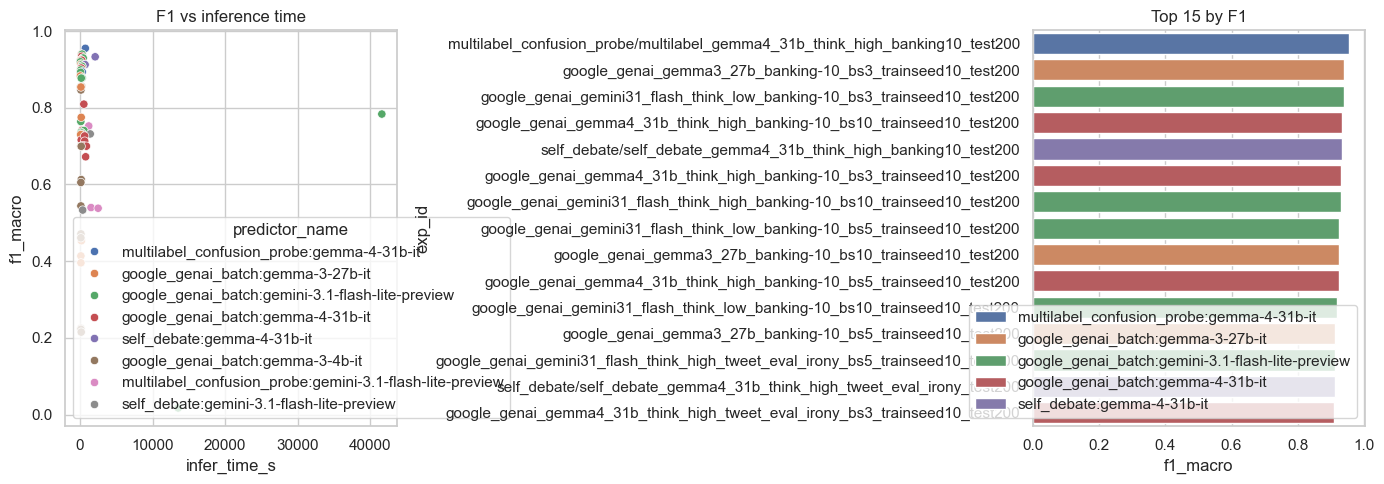

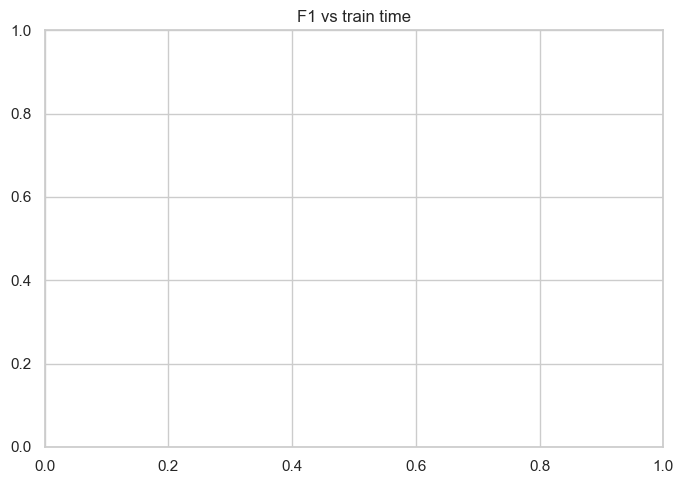

In [15]:
# --- Seaborn overview plots ---

# Filter to the chosen dataset for clean visuals
m = meta_view.copy()
m = m[m["dataset_name"] == DATASET].copy() if "DATASET" in globals() and "dataset_name" in m.columns else m

# Drop missing metrics for plotting
m1 = m.dropna(subset=[c for c in ["f1_macro", "accuracy", "infer_time_s"] if c in m.columns]).copy()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

if {"infer_time_s", "f1_macro"}.issubset(m1.columns):
    sns.scatterplot(data=m1, x="infer_time_s", y="f1_macro", hue="predictor_name", ax=ax[0])
    ax[0].set_title("F1 vs inference time")

if {"f1_macro", "exp_id"}.issubset(m1.columns):
    top = m1.sort_values("f1_macro", ascending=False).head(15)
    sns.barplot(data=top, y="exp_id", x="f1_macro", hue="predictor_name", dodge=False, ax=ax[1])
    ax[1].set_title("Top 15 by F1")
    ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# Optional: train time vs F1 (useful for SetFit)
if {"train_time_s", "f1_macro"}.issubset(m.columns):
    m2 = m.dropna(subset=["train_time_s", "f1_macro"]).copy()
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=m2, x="train_time_s", y="f1_macro", hue="predictor_name")
    plt.title("F1 vs train time")
    plt.tight_layout()
    plt.show()

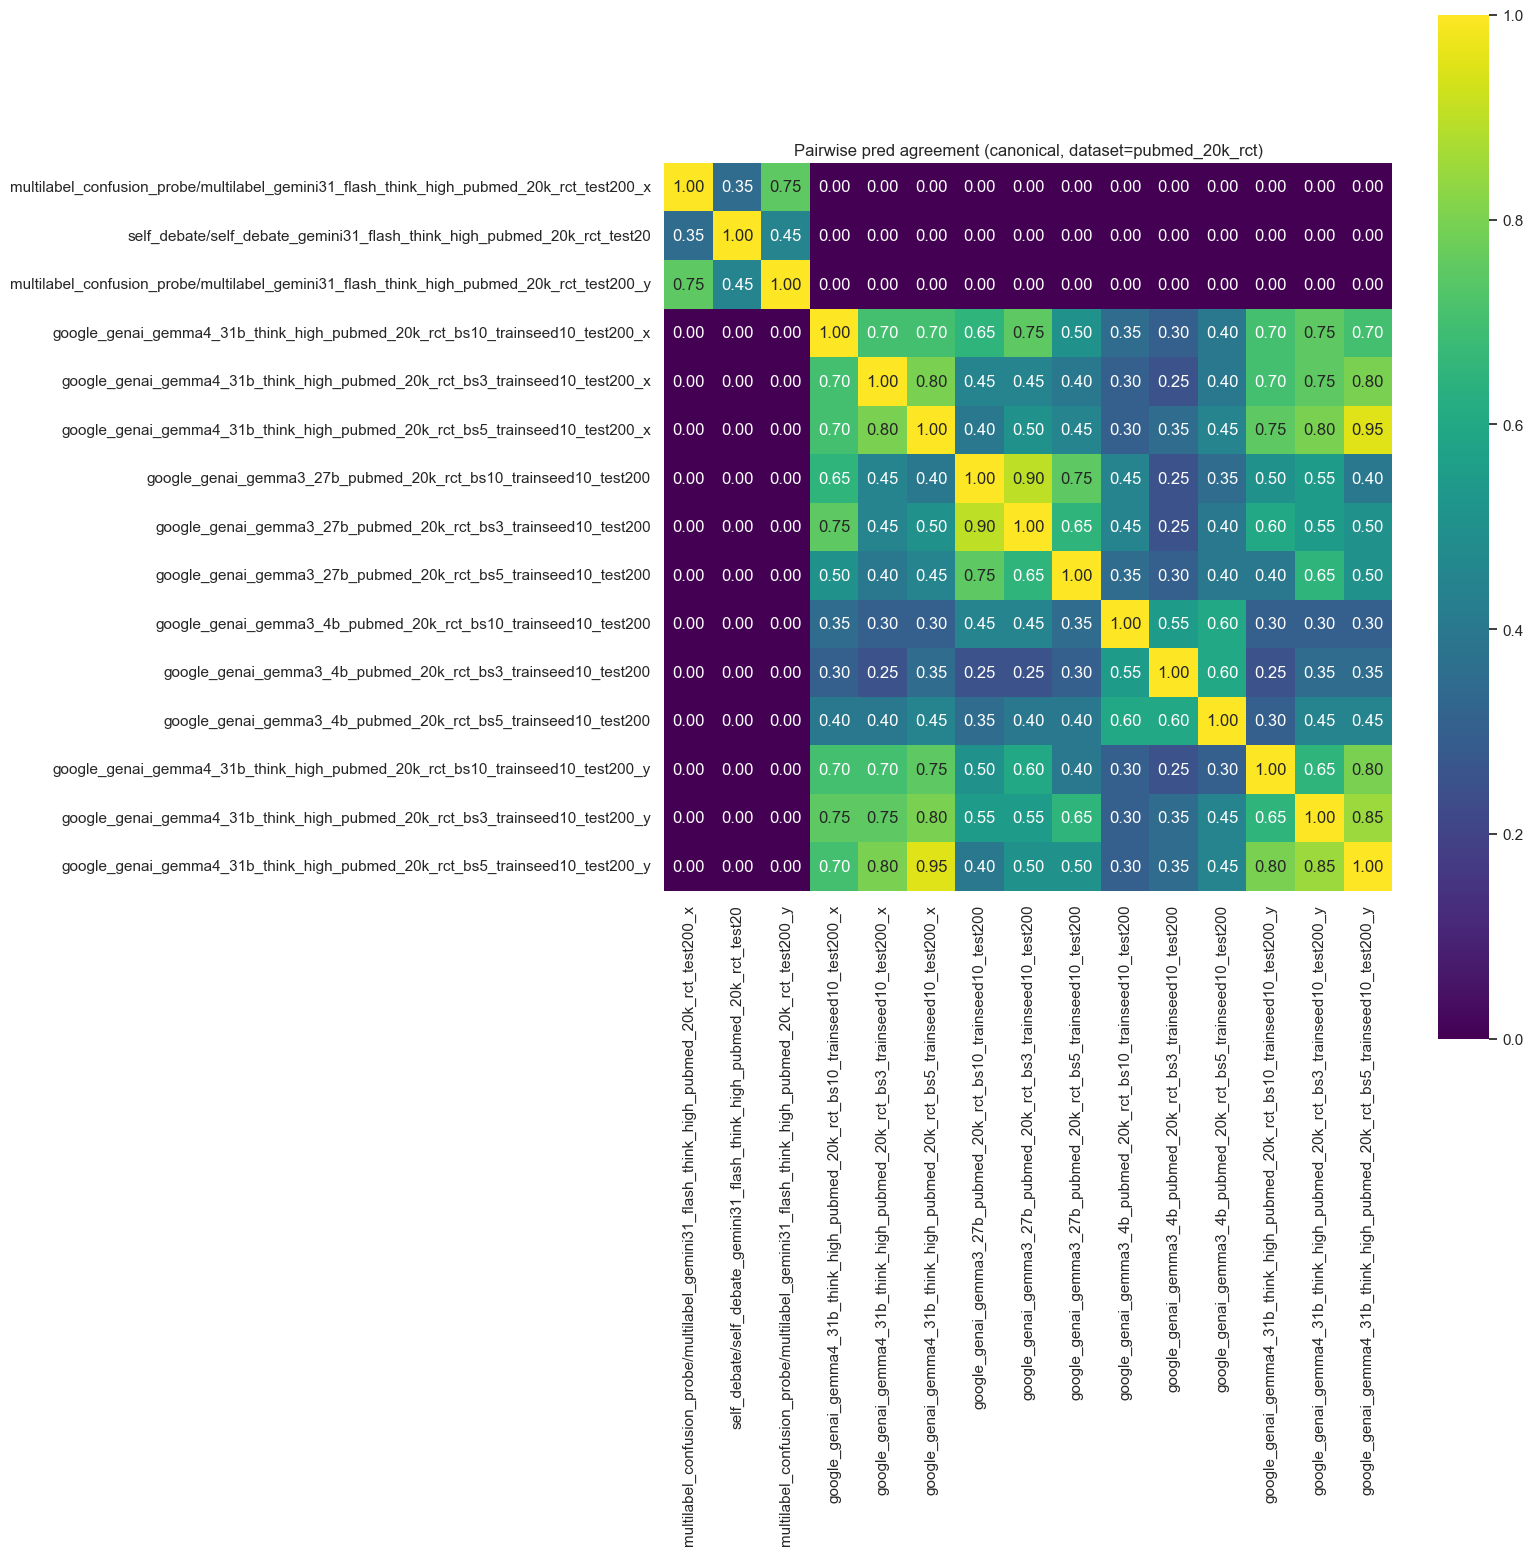

In [19]:
# --- Pairwise prediction agreement (canonical labels; not Pearson correlation) ---

if "a_df" in globals() and hasattr(a_df, "empty") and not a_df.empty:
    plt.figure(figsize=(0.8 * len(a_df.columns) + 4, 0.8 * len(a_df) + 4))
    sns.heatmap(a_df, annot=True, fmt=".2f", cmap="viridis", vmin=0.0, vmax=1.0, square=True)
    plt.title(f"Pairwise pred agreement (canonical, dataset={DATASET})")
    plt.tight_layout()
    plt.show()
else:
    print("No agreement matrix available (a_df is empty). Make sure you built cmp_df for a single dataset.")

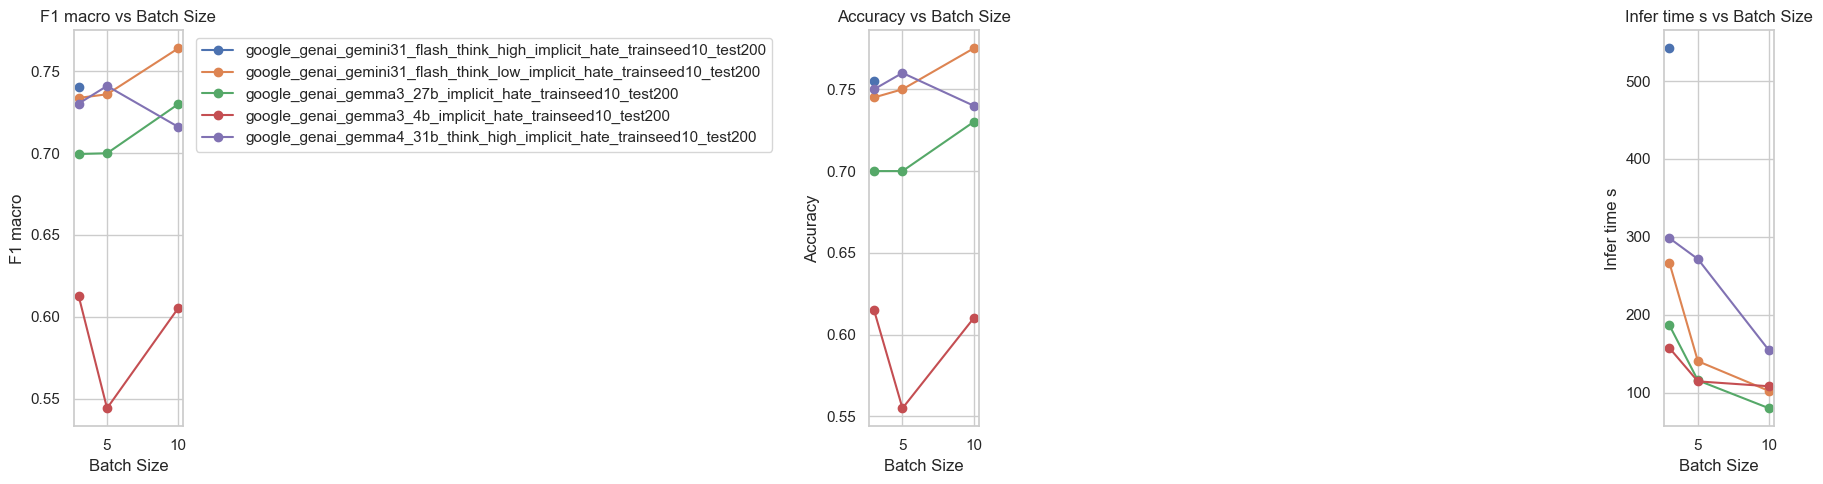

,exp_id,batch_size,modelcfg,f1_macro,accuracy,infer_time_s
0,google_genai_gemini31_flash_think_high_implicit_hate_bs3_trainseed10_test200,3,google_genai_gemini31_flash_think_high_implicit_hate_trainseed10_test200,0.740679,0.755,541.898820
8,google_genai_gemini31_flash_think_low_implicit_hate_bs3_trainseed10_test200,3,google_genai_gemini31_flash_think_low_implicit_hate_trainseed10_test200,0.733814,0.745,266.489324
9,google_genai_gemini31_flash_think_low_implicit_hate_bs5_trainseed10_test200,5,google_genai_gemini31_flash_think_low_implicit_hate_trainseed10_test200,0.736036,0.750,140.482698
7,google_genai_gemini31_flash_think_low_implicit_hate_bs10_trainseed10_test200,10,google_genai_gemini31_flash_think_low_implicit_hate_trainseed10_test200,0.764095,0.775,102.305361
17,google_genai_gemma3_27b_implicit_hate_bs3_trainseed10_test200,3,google_genai_gemma3_27b_implicit_hate_trainseed10_test200,0.699519,0.700,186.464349
18,google_genai_gemma3_27b_implicit_hate_bs5_trainseed10_test200,5,google_genai_gemma3_27b_implicit_hate_trainseed10_test200,0.699970,0.700,115.885272
16,google_genai_gemma3_27b_implicit_hate_bs10_trainseed10_test200,10,google_genai_gemma3_27b_implicit_hate_trainseed10_test200,0.729973,0.730,80.090047
29,google_genai_gemma3_4b_implicit_hate_bs3_trainseed10_test200,3,google_genai_gemma3_4b_implicit_hate_trainseed10_test200,0.612822,0.615,157.336824
30,google_genai_gemma3_4b_implicit_hate_bs5_trainseed10_test200,5,google_genai_gemma3_4b_implicit_hate_trainseed10_test200,0.544046,0.555,114.602680
28,google_genai_gemma3_4b_implicit_hate_bs10_trainseed10_test200,10,google_genai_gemma3_4b_implicit_hate_trainseed10_test200,0.605223,0.610,108.315491


In [33]:
# --- Visualize report/metric differences between various batch sizes (bs*) ---

# This code compares and visualizes *report-level* (aggregated) metrics like accuracy, f1_macro, etc.
# across batch sizes for each model configuration, instead of raw per-sample disagreements.

import re

def extract_bs_from_exp_id(exp_id):
    m = re.search(r'_bs(\d+)_', exp_id)
    return int(m.group(1)) if m else None

def extract_modelcfg_from_exp_id(exp_id):
    # Remove batch size segment but keep everything else for model+config
    # e.g. google_genai_gemini31_flash_think_low_banking-10_bs3_trainseed10_test200 → google_genai_gemini31_flash_think_low_banking-10__trainseed10_test200
    s = re.sub(r'_bs\d+_', '_', exp_id)
    return s

# Only keep rows relating to batch size experiments of the current DATASET
filtered = meta_view.copy()
if "DATASET" in globals() and "dataset_name" in filtered.columns:
    filtered = filtered[filtered["dataset_name"] == DATASET].copy()
if "exp_id" not in filtered.columns:
    # Defensive: if no exp_id col, nothing to visualize
    print("meta_view must include 'exp_id' for batch size report comparison.")
else:
    # Annotate for batch size and model config
    filtered = filtered.assign(
        batch_size=filtered["exp_id"].apply(extract_bs_from_exp_id),
        modelcfg=filtered["exp_id"].apply(extract_modelcfg_from_exp_id)
    )

    # Only consider valid batch-size runs
    filtered = filtered[filtered["batch_size"].notnull()]
    # Choose which metrics we want to plot
    metric_cols = [c for c in ["f1_macro", "accuracy", "precision_macro", "recall_macro", "infer_time_s"] if c in filtered.columns]
    if not metric_cols:
        print("No metric columns found to visualize.")
    else:
        # High-level: for each modelcfg, plot metric vs batch size
        import matplotlib.pyplot as plt

        n_metrics = len(metric_cols)
        fig, axes = plt.subplots(1, n_metrics, figsize=(6 * n_metrics, 5))
        if n_metrics == 1:
            axes = [axes]

        for mi, metric in enumerate(metric_cols):
            for model, g in filtered.groupby("modelcfg"):
                g = g.sort_values("batch_size")
                axes[mi].plot(
                    g["batch_size"], g[metric], marker="o", label=str(model)
                )
            axes[mi].set_title(f"{metric.replace('_', ' ').capitalize()} vs Batch Size")
            axes[mi].set_xlabel("Batch Size")
            axes[mi].set_ylabel(metric.replace("_", " ").capitalize())
            axes[mi].grid(True)
        axes[0].legend(bbox_to_anchor=(1.05, 1), loc="upper left")

        plt.tight_layout()
        plt.show()

        # Optional: Show the actual table of all batch size report runs
        from IPython.display import display
        display(filtered[["exp_id", "batch_size", "modelcfg"] + metric_cols].sort_values(["modelcfg", "batch_size"]))


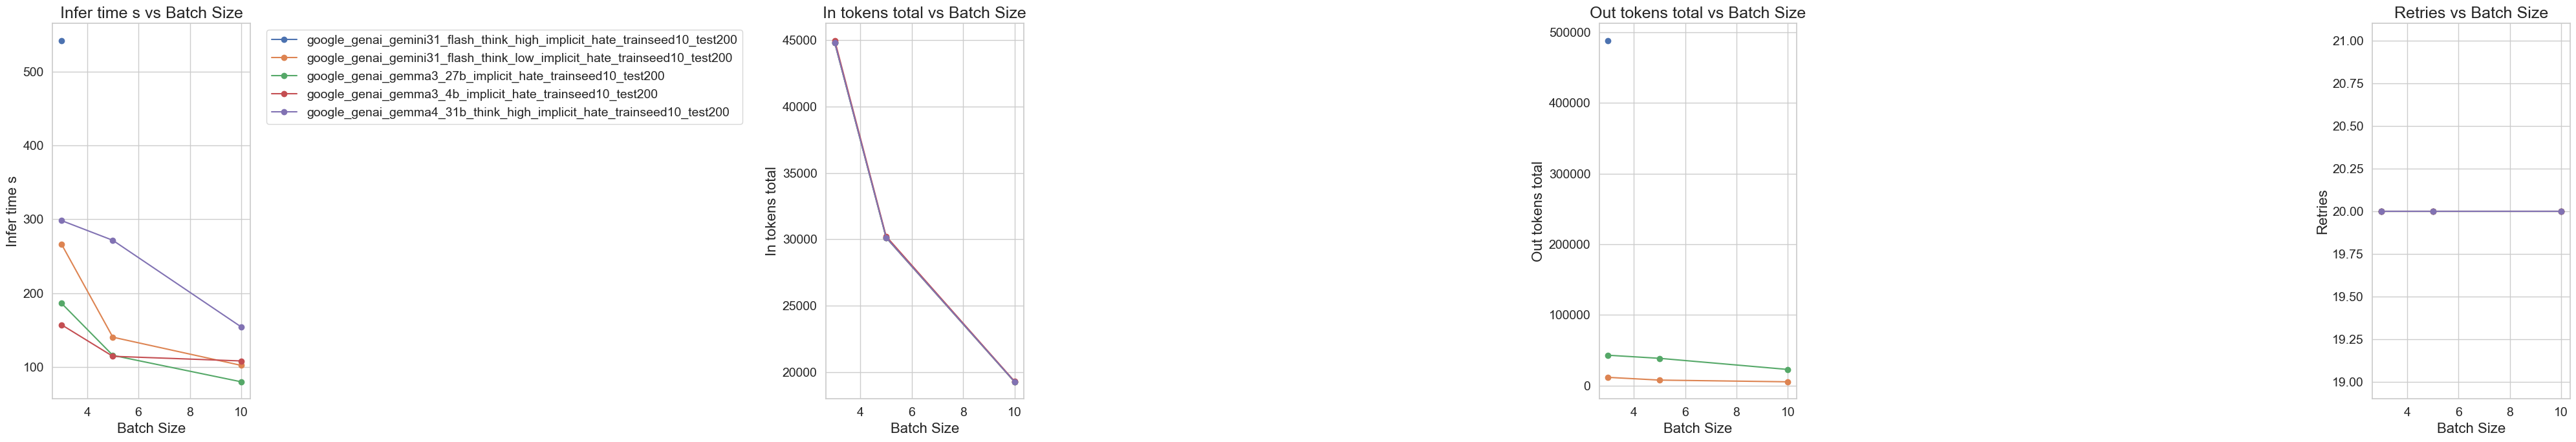

,exp_id,batch_size,modelcfg,infer_time_s,in_tokens_total,out_tokens_total,retries
0,google_genai_gemini31_flash_think_high_implicit_hate_bs3_trainseed10_test200,3,google_genai_gemini31_flash_think_high_implicit_hate_trainseed10_test200,541.898820,44800,487975.0,20
8,google_genai_gemini31_flash_think_low_implicit_hate_bs3_trainseed10_test200,3,google_genai_gemini31_flash_think_low_implicit_hate_trainseed10_test200,266.489324,44800,11836.0,20
9,google_genai_gemini31_flash_think_low_implicit_hate_bs5_trainseed10_test200,5,google_genai_gemini31_flash_think_low_implicit_hate_trainseed10_test200,140.482698,30138,7964.0,20
7,google_genai_gemini31_flash_think_low_implicit_hate_bs10_trainseed10_test200,10,google_genai_gemini31_flash_think_low_implicit_hate_trainseed10_test200,102.305361,19281,5542.0,20
17,google_genai_gemma3_27b_implicit_hate_bs3_trainseed10_test200,3,google_genai_gemma3_27b_implicit_hate_trainseed10_test200,186.464349,44800,NaN,20
18,google_genai_gemma3_27b_implicit_hate_bs5_trainseed10_test200,5,google_genai_gemma3_27b_implicit_hate_trainseed10_test200,115.885272,30138,NaN,20
16,google_genai_gemma3_27b_implicit_hate_bs10_trainseed10_test200,10,google_genai_gemma3_27b_implicit_hate_trainseed10_test200,80.090047,19281,NaN,20
29,google_genai_gemma3_4b_implicit_hate_bs3_trainseed10_test200,3,google_genai_gemma3_4b_implicit_hate_trainseed10_test200,157.336824,44968,NaN,20
30,google_genai_gemma3_4b_implicit_hate_bs5_trainseed10_test200,5,google_genai_gemma3_4b_implicit_hate_trainseed10_test200,114.602680,30232,NaN,20
28,google_genai_gemma3_4b_implicit_hate_bs10_trainseed10_test200,10,google_genai_gemma3_4b_implicit_hate_trainseed10_test200,108.315491,19318,NaN,20


In [34]:
# Visualization of token usage, timing, and system metrics

if "filtered" in locals():
    import matplotlib.pyplot as plt
    import numpy as np
    from IPython.display import display

    # Pick relevant system metric columns if present
    system_metric_candidates = [
        "infer_time_s", "total_tokens", "in_tokens_total", "out_tokens_total",
        "cost_usd", "n_warnings", "n_errors", "retries", "cpu_time", "gpu_time"
    ]
    system_metric_cols = [c for c in system_metric_candidates if c in filtered.columns and filtered[c].notnull().any()]

    if not system_metric_cols:
        print("No system metric columns available for visualization.")
    else:
        # Make the plots much larger for easier visual comparison
        n_metrics = len(system_metric_cols)
        fig, axes = plt.subplots(1, n_metrics, figsize=(10 * n_metrics, 7))
        if n_metrics == 1:
            axes = [axes]

        for mi, metric in enumerate(system_metric_cols):
            ax = axes[mi]
            for model, g in filtered.groupby("modelcfg"):
                g = g.sort_values("batch_size")
                # Handle cases where metric might be all NaN for this model
                if g[metric].notnull().any():
                    ax.plot(
                        g["batch_size"], g[metric], marker="o", label=str(model)
                    )
            ax.set_title(f"{metric.replace('_', ' ').capitalize()} vs Batch Size", fontsize=18)
            ax.set_xlabel("Batch Size", fontsize=16)
            ax.set_ylabel(metric.replace("_", " ").capitalize(), fontsize=16)
            ax.grid(True)
            ax.tick_params(axis='both', labelsize=14)
        axes[0].legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=14)
        plt.tight_layout()
        plt.show()

        # Optional: show summary statistics for these metrics
        system_view = filtered[["exp_id", "batch_size", "modelcfg"] + system_metric_cols].sort_values(["modelcfg", "batch_size"])
        display(system_view)

    # Additional visualization for tokens specifically (line plots together if available)
    token_cols = [col for col in ["total_tokens", "input_tokens", "output_tokens"] if col in filtered.columns and filtered[col].notnull().any()]
    if token_cols:
        plt.figure(figsize=(14, 8))
        for token_col in token_cols:
            # For each model config, plot tokens vs. batch size
            for model, g in filtered.groupby("modelcfg"):
                g = g.sort_values("batch_size")
                if g[token_col].notnull().any():
                    plt.plot(
                        g["batch_size"],
                        g[token_col],
                        marker="o",
                        label=f"{token_col.replace('_', ' ').capitalize()} [{model}]"
                    )
        plt.title("Token usage vs Batch Size", fontsize=18)
        plt.xlabel("Batch Size", fontsize=16)
        plt.ylabel("Tokens", fontsize=16)
        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=14)
        plt.tight_layout()
        plt.show()
else:
    print("No 'filtered' DataFrame found to plot system metric reports.")